# 0. Random Walk Graph Traversal Dataset Generation and Topology Analysis
## Empirical Characterization of Stochastic Algorithmic Traces and Underlying Graph Topologies

### Executive Summary & Educational Motivation
In neural algorithmic reasoning, understanding the structural and statistical properties of execution traces is critical for evaluating model generalization. Depth-First Search (DFS) traces follow strict tree-structured systematic exploration patterns, making path extraction relatively straightforward for sequence models.

In contrast, **Random Walk (RW)** execution traces represent stochastic, unguided exploration over unknown graphs. A random walk agent transitions uniformly at random among available adjacent neighbors until it discovers destination node $g$. This introduces unstructured loop structures, frequent node revisits, non-systematic regressions, and higher contextual entropy.

This notebook constructs a standardized procedural dataset of goal-terminated Random Walk traversal traces while maintaining identical sequence length bounds ($30 \le K \le 50$) and vocabulary parameters ($V=42$) as the DFS dataset. The dataset is serialized directly to **Google Drive** (with automatic local fallback to `data/graph_rw_dataset.pt`) for cross-architecture benchmarking.

---

### Mathematical Problem Formulation

#### 1. Graph Generation and Adjacency Structure
Let $G = (V, E)$ be an undirected, unweighted connected graph with $N$ nodes ($20 \le N \le 35$), where node identifiers are randomly permuted from a fixed vocabulary $\mathcal{V}_{nodes} = \{0, 1, \dots, 39\}$.

#### 2. Goal-Terminated Random Walk Traversal Trace
A Random Walk agent starting at root node $s \in V$ selects adjacent neighbors uniformly at random:
$$P(t_{k+1} = v \mid t_k = u) = \frac{1}{\text{deg}(u)}$$
The walk **terminates immediately** upon discovering destination node $g \in V$, yielding the trace:
$$T = [t_1, t_2, \dots, t_K]$$
where $t_1 = s$, $t_K = g$, $t_k \neq g$ for all $1 \le k < K$, and $30 \le K \le 50$.

#### 3. Node Backtraces and Stochastic Regressions
In a Random Walk, return steps ($t_k = t_{k-2}$) occur stochastically rather than systematically. We track the **Node Backtrace Count** $B(v)$ defining how many times node $v$ induced an immediate step regression during the walk:
$$B(v) = \sum_{k=3}^K \mathbb{I}\big(t_k = t_{k-2} \text{ and } t_{k-1} = v\big)$$

#### 4. Shortest Path Target
The true shortest path $P^*$ between $s$ and $g$ in $G_T$ (the graph induced by trace $T$) is represented as:
$$P^* = [p_1^*, p_2^*, \dots, p_M^*]$$
where $p_1^* = s$, $p_M^* = g$, and $10 \le M \le 20$.


In [1]:
# Cell 1: Environment Setup, Seeds, and Google Drive Path Configuration

import os
import random
import time
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

# Ensure charts and data directories exist relative to repo root / working dir
if os.path.basename(os.getcwd()) == "graphs":
    os.makedirs("../charts", exist_ok=True)
    os.makedirs("charts", exist_ok=True)
    os.makedirs("data", exist_ok=True)
    LOCAL_DATA_DIR = "data"
else:
    os.makedirs("charts", exist_ok=True)
    os.makedirs("graphs/charts", exist_ok=True)
    os.makedirs("graphs/data", exist_ok=True)
    LOCAL_DATA_DIR = "graphs/data"

# Set PyTorch CPU thread count to 1 for reproducible, efficient single-core execution
torch.set_num_threads(1)

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

# Google Drive Mount & Dataset Path Resolution
def setup_data_dir():
    try:
        from google.colab import drive
        drive.mount('/content/drive')
        save_dir = "/content/drive/MyDrive/graph_data"
    except ImportError:
        save_dir = LOCAL_DATA_DIR

    os.makedirs(save_dir, exist_ok=True)
    print(f"Dataset path initialized: {save_dir}")
    return save_dir

DATA_DIR = setup_data_dir()
DATASET_PATH = os.path.join(DATA_DIR, "graph_rw_dataset.pt")


Mounted at /content/drive
Dataset path initialized: /content/drive/MyDrive/graph_data


### Dataset Construction: Candidate-Filtered Goal-Terminated Random Walk Traces
To guarantee challenging stochastic exploration traces:
1. **Goal-Terminated Random Walk**: Walk stops **immediately** upon discovering the goal node $g$, so $g$ appears **exactly once** at the final position (`trace[-1] == g`).
2. **Identical Vocabulary & Sequence Bounds**:
   - Vocabulary: $V=42$, `PAD_TOKEN=40`, `STOP_TOKEN=41`
   - Random Walk Trace Length $K$: $30 \le K \le 50$
   - Shortest Path Target Length $M$: $10 \le M \le 20$
3. **Randomized Token Permutation**: Node identifiers are randomly permuted across $\{0, 1, \dots, 39\}$ for every sample.


In [2]:
# Cell 2: Procedural Random Walk Candidate Sampling, Filtering, and Metrics

VOCAB_SIZE = 42
PAD_TOKEN = 40
STOP_TOKEN = 41
MAX_SRC_LEN = 50
MAX_TGT_LEN = 21

def generate_single_rw_candidate(min_nodes=20, max_nodes=35, max_trace_len=50, min_trace_len=30, min_sp_len=10, max_sp_len=20):
    for attempt in range(500):
        n = random.randint(min_nodes, max_nodes)
        G = nx.random_labeled_tree(n)

        # Add random extra edges to create loops and alternate paths
        extra_edges = random.randint(2, 6)
        for _ in range(extra_edges):
            u, v = random.sample(range(n), 2)
            if u != v:
                G.add_edge(u, v)

        start = random.choice(range(n))
        goal = random.choice([v for v in range(n) if v != start])

        # Goal-terminated Random Walk traversal
        trace = [start]
        curr = start
        while len(trace) < max_trace_len + 5:
            if curr == goal:
                break
            neighbors = list(G.neighbors(curr))
            curr = random.choice(neighbors)
            trace.append(curr)

        if trace[-1] != goal or trace.count(goal) != 1:
            continue

        if not (min_trace_len <= len(trace) <= max_trace_len):
            continue

        # Reconstruct graph from trace
        G_trace = nx.Graph()
        for i in range(len(trace) - 1):
            G_trace.add_edge(trace[i], trace[i+1])

        if not nx.has_path(G_trace, start, goal):
            continue

        sp = nx.shortest_path(G_trace, source=start, target=goal)

        if min_sp_len <= len(sp) <= max_sp_len:
            # Backtrace metric calculation
            backtracks = 0
            node_backtraces = {node: 0 for node in G_trace.nodes()}
            for i in range(2, len(trace)):
                if trace[i] == trace[i-2]:
                    backtracks += 1
                    node_backtraces[trace[i-1]] += 1

            # Token permutation over vocabulary of 40 node IDs
            vocab = list(range(40))
            perm = random.sample(vocab, n)
            mapping = {i: perm[i] for i in range(n)}

            perm_trace = [mapping[x] for x in trace]
            perm_sp = [mapping[x] for x in sp]
            G_perm = nx.relabel_nodes(G_trace, mapping)
            perm_node_backtraces = {mapping[k]: v for k, v in node_backtraces.items() if k in mapping}

            return perm_trace, perm_sp, G_perm, mapping, backtracks, perm_node_backtraces

    return None

def generate_filtered_rw_dataset(target_samples=4000):
    dataset = []
    attempts = 0
    max_attempts = target_samples * 20
    while len(dataset) < target_samples and attempts < max_attempts:
        sample = generate_single_rw_candidate()
        attempts += 1
        if sample is not None:
            dataset.append(sample)
    return dataset

print("Generating 4,000 candidate-filtered Random Walk graph samples (src: 30-50, tgt: 10-20)...")
start_time = time.time()
raw_data = generate_filtered_rw_dataset(4000)
print(f"Generated {len(raw_data)} samples in {time.time() - start_time:.2f} seconds.")

# Dataset Split: Train (3000), Val (500), Test (500)
train_raw = raw_data[:3000]
val_raw = raw_data[3000:3500]
test_raw = raw_data[3500:4000]

print(f"Splits constructed: Train={len(train_raw)}, Val={len(val_raw)}, Test={len(test_raw)}")


Generating 4,000 candidate-filtered Random Walk graph samples (src: 30-50, tgt: 10-20)...
Generated 4000 samples in 44.94 seconds.
Splits constructed: Train=3000, Val=500, Test=500


### Dataset Serialization to Drive / Local Storage
We serialize the raw processed dataset using PyTorch `torch.save()` into `graph_rw_dataset.pt`.


In [3]:
# Cell 3: Save Processed Dataset to Drive / Local Directory

dataset_payload = {
    'train': train_raw,
    'val': val_raw,
    'test': test_raw,
    'vocab_size': VOCAB_SIZE,
    'pad_token': PAD_TOKEN,
    'stop_token': STOP_TOKEN,
    'max_src_len': MAX_SRC_LEN,
    'max_tgt_len': MAX_TGT_LEN,
    'dataset_flavor': 'rw'
}

torch.save(dataset_payload, DATASET_PATH)
file_size_mb = os.path.getsize(DATASET_PATH) / (1024 * 1024)
print(f"Random Walk Dataset successfully saved to '{DATASET_PATH}' ({file_size_mb:.2f} MB).")


Random Walk Dataset successfully saved to '/content/drive/MyDrive/graph_data/graph_rw_dataset.pt' (3.38 MB).


### Empirical Analysis of Dataset & Graph Topologies
We compute key graph-theoretic and algorithmic trace properties across the Random Walk dataset:
1. **Node & Edge Statistics**: Node counts, edge counts, and average degree.
2. **Trace & Path Lengths**: Sequence lengths ($30 \le K \le 50$, $10 \le M \le 20$).
3. **Stochastic Backtracks**: Count of immediate regressions ($t_k = t_{k-2}$).
4. **Compression Ratio**: $\eta = M / K$.


In [4]:
# Cell 4: Compute Comprehensive Graph Topological & Backtrace Statistics

degrees = []
node_counts = []
edge_counts = []
trace_lengths = []
sp_lengths = []
compression_ratios = []
backtrack_counts = []
max_regressions_per_node = []

for trace, sp, G, mapping, backtracks, node_backtraces in raw_data:
    node_counts.append(G.number_of_nodes())
    edge_counts.append(G.number_of_edges())

    deg_list = [d for _, d in G.degree()]
    degrees.extend(deg_list)

    K = len(trace)
    M = len(sp)
    trace_lengths.append(K)
    sp_lengths.append(M)
    compression_ratios.append(M / K)
    backtrack_counts.append(backtracks)

    max_reg = max(node_backtraces.values()) if node_backtraces else 0
    max_regressions_per_node.append(max_reg)

print("=" * 70)
print("             RANDOM WALK GRAPH & TRAVERSAL DATASET STATISTICS")
print("=" * 70)
print(f"{'Metric':<38} | {'Mean ± Std':<15} | {'[Min, Max]':<10}")
print("-" * 70)
print(f"{'Node Count (N)':<38} | {np.mean(node_counts):.2f} ± {np.std(node_counts):.2f}   | [{np.min(node_counts)}, {np.max(node_counts)}]")
print(f"{'Edge Count (|E|)':<38} | {np.mean(edge_counts):.2f} ± {np.std(edge_counts):.2f}   | [{np.min(edge_counts)}, {np.max(edge_counts)}]")
print(f"{'Average Node Degree (<k>)':<38} | {np.mean(degrees):.2f} ± {np.std(degrees):.2f}   | [{np.min(degrees)}, {np.max(degrees)}]")
print(f"{'RW Trace Length (K) [Target 30-50]':<38} | {np.mean(trace_lengths):.2f} ± {np.std(trace_lengths):.2f}   | [{np.min(trace_lengths)}, {np.max(trace_lengths)}]")
print(f"{'Shortest Path Length (M) [Target 10-20]':<38} | {np.mean(sp_lengths):.2f} ± {np.std(sp_lengths):.2f}   | [{np.min(sp_lengths)}, {np.max(sp_lengths)}]")
print(f"{'Compression Ratio (M / K)':<38} | {np.mean(compression_ratios):.3f} ± {np.std(compression_ratios):.3f} | [{np.min(compression_ratios):.2f}, {np.max(compression_ratios):.2f}]")
print(f"{'Total Backtracks per Trace':<38} | {np.mean(backtrack_counts):.2f} ± {np.std(backtrack_counts):.2f}   | [{np.min(backtrack_counts)}, {np.max(backtrack_counts)}]")
print(f"{'Max Regressions per Node':<38} | {np.mean(max_regressions_per_node):.2f} ± {np.std(max_regressions_per_node):.2f}   | [{np.min(max_regressions_per_node)}, {np.max(max_regressions_per_node)}]")
print("=" * 70)


             RANDOM WALK GRAPH & TRAVERSAL DATASET STATISTICS
Metric                                 | Mean ± Std      | [Min, Max]
----------------------------------------------------------------------
Node Count (N)                         | 15.97 ± 2.34   | [10, 24]
Edge Count (|E|)                       | 15.29 ± 2.53   | [9, 24]
Average Node Degree (<k>)              | 1.92 ± 0.77   | [1, 6]
RW Trace Length (K) [Target 30-50]     | 39.83 ± 6.14   | [30, 50]
Shortest Path Length (M) [Target 10-20] | 11.09 ± 1.36   | [10, 19]
Compression Ratio (M / K)              | 0.285 ± 0.055 | [0.20, 0.53]
Total Backtracks per Trace             | 16.44 ± 4.34   | [5, 32]
Max Regressions per Node               | 3.59 ± 1.43   | [1, 13]


### Publication-Quality Analytical Plots
We generate and save analytical figures for Random Walk topologies:
1. **Degree & Length Distributions**: `charts/graph_rw_topology_distributions.png`
2. **Trace Efficiency & Backtracking Scatter**: `charts/graph_rw_compression_analysis.png`
3. **Sample Graph Layouts & Traversal Traces**: `charts/graph_rw_sample_topologies.png`


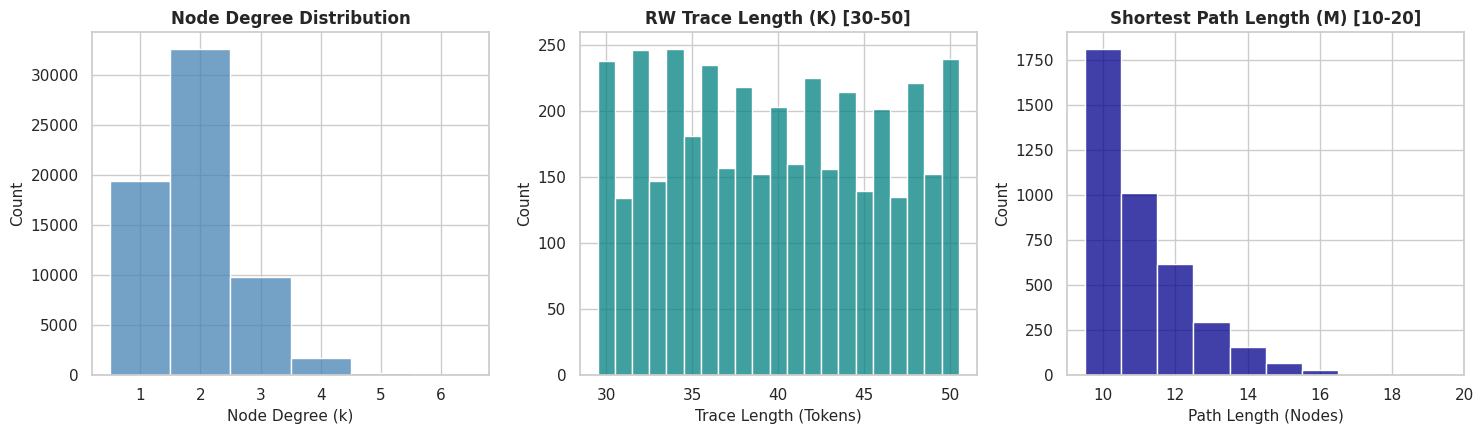

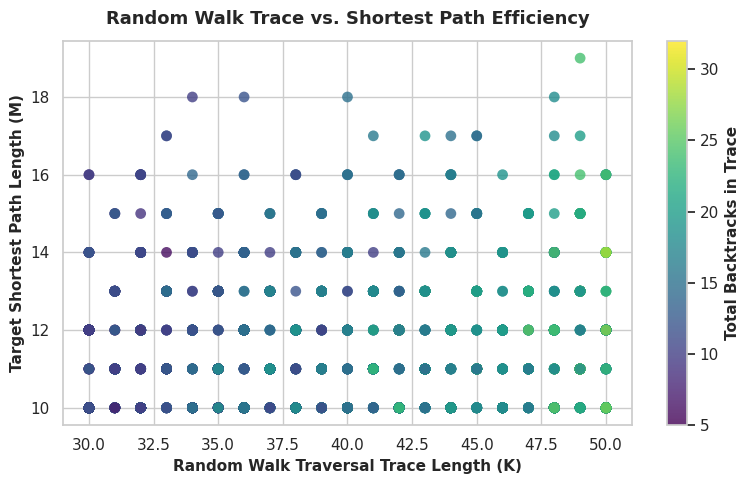

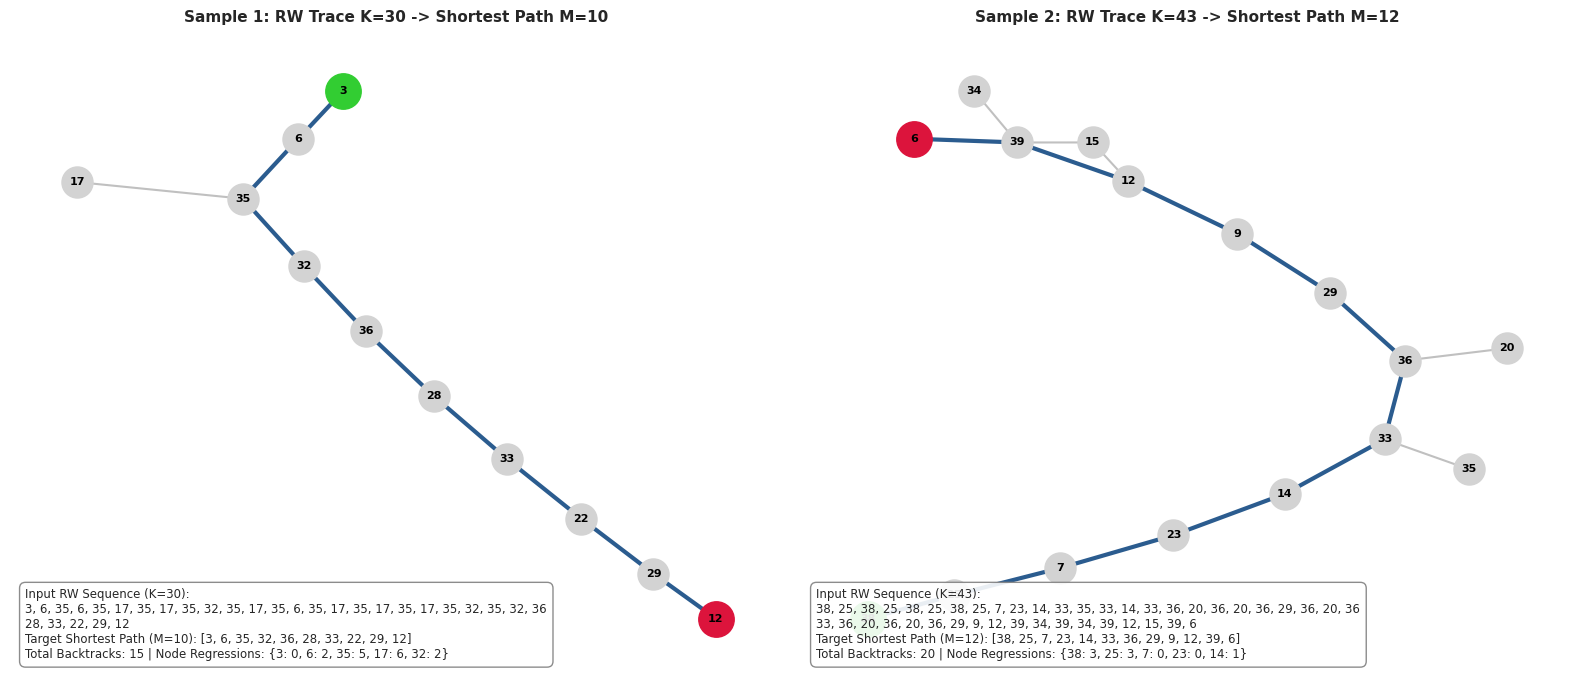

All Random Walk publication-quality topology figures successfully generated and saved.


In [5]:
# Cell 5: Generate Publication-Quality Analytical Figures

sns.set_theme(style="whitegrid", palette="mako")

# Figure 1: Topology Distributions
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

sns.histplot(degrees, discrete=True, kde=False, color='steelblue', ax=axes[0])
axes[0].set_title('Node Degree Distribution', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Node Degree (k)', fontsize=11)
axes[0].set_ylabel('Count', fontsize=11)

sns.histplot(trace_lengths, discrete=True, kde=False, color='teal', ax=axes[1])
axes[1].set_title('RW Trace Length (K) [30-50]', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Trace Length (Tokens)', fontsize=11)
axes[1].set_ylabel('Count', fontsize=11)

sns.histplot(sp_lengths, discrete=True, kde=False, color='darkblue', ax=axes[2])
axes[2].set_title('Shortest Path Length (M) [10-20]', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Path Length (Nodes)', fontsize=11)
axes[2].set_ylabel('Count', fontsize=11)

plt.tight_layout()
if os.path.basename(os.getcwd()) == "graphs":
    plt.savefig("../charts/graph_rw_topology_distributions.png", dpi=300, bbox_inches='tight')
    plt.savefig("charts/graph_rw_topology_distributions.png", dpi=300, bbox_inches='tight')
else:
    plt.savefig("charts/graph_rw_topology_distributions.png", dpi=300, bbox_inches='tight')
    plt.savefig("graphs/charts/graph_rw_topology_distributions.png", dpi=300, bbox_inches='tight')
plt.show()

# Figure 2: Trace Compression & Backtracking Scatter Analysis
fig, ax = plt.subplots(figsize=(8, 5))
scatter = ax.scatter(trace_lengths, sp_lengths, c=backtrack_counts, cmap='viridis', alpha=0.8, s=60, edgecolors='none')
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Total Backtracks in Trace', fontsize=11, fontweight='bold')

ax.set_title('Random Walk Trace vs. Shortest Path Efficiency', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Random Walk Traversal Trace Length (K)', fontsize=11, fontweight='bold')
ax.set_ylabel('Target Shortest Path Length (M)', fontsize=11, fontweight='bold')

plt.tight_layout()
if os.path.basename(os.getcwd()) == "graphs":
    plt.savefig("../charts/graph_rw_compression_analysis.png", dpi=300, bbox_inches='tight')
    plt.savefig("charts/graph_rw_compression_analysis.png", dpi=300, bbox_inches='tight')
else:
    plt.savefig("charts/graph_rw_compression_analysis.png", dpi=300, bbox_inches='tight')
    plt.savefig("graphs/charts/graph_rw_compression_analysis.png", dpi=300, bbox_inches='tight')
plt.show()

# Figure 3: Sample Graph Layouts
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for i in range(2):
    trace_sample, sp_sample, G_sample, mapping_sample, backtracks_sample, node_backtraces_sample = raw_data[i]
    pos = nx.spring_layout(G_sample, seed=42+i)

    # Base graph
    nx.draw_networkx_nodes(G_sample, pos, ax=axes[i], node_color='lightgray', node_size=500)
    nx.draw_networkx_edges(G_sample, pos, ax=axes[i], edge_color='silver', width=1.5)

    # Highlight Shortest Path
    sp_edges = [(sp_sample[k], sp_sample[k+1]) for k in range(len(sp_sample)-1)]
    nx.draw_networkx_edges(G_sample, pos, ax=axes[i], edgelist=sp_edges, edge_color='#2b5c8f', width=3.0)

    # Start and Goal
    nx.draw_networkx_nodes(G_sample, pos, ax=axes[i], nodelist=[sp_sample[0]], node_color='limegreen', node_size=650)
    nx.draw_networkx_nodes(G_sample, pos, ax=axes[i], nodelist=[sp_sample[-1]], node_color='crimson', node_size=650)

    labels = {node: str(node) for node in G_sample.nodes()}
    nx.draw_networkx_labels(G_sample, pos, ax=axes[i], labels=labels, font_size=8, font_weight='bold')

    # Format original input sequence as text
    trace_text = f"Input RW Sequence (K={len(trace_sample)}):\n" + ", ".join(map(str, trace_sample[:25])) + "\n" + ", ".join(map(str, trace_sample[25:]))
    sp_text = f"Target Shortest Path (M={len(sp_sample)}): {sp_sample}"
    backtrace_text = f"Total Backtracks: {backtracks_sample} | Node Regressions: {dict(list(node_backtraces_sample.items())[:5])}"

    axes[i].text(0.02, 0.02, f"{trace_text}\n{sp_text}\n{backtrace_text}",
                 transform=axes[i].transAxes, fontsize=8.5, verticalalignment='bottom',
                 bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.9, edgecolor='gray'))

    axes[i].set_title(f"Sample {i+1}: RW Trace K={len(trace_sample)} -> Shortest Path M={len(sp_sample)}", fontsize=11, fontweight='bold', pad=10)
    axes[i].axis('off')

plt.tight_layout()
if os.path.basename(os.getcwd()) == "graphs":
    plt.savefig("../charts/graph_rw_sample_topologies.png", dpi=300, bbox_inches='tight')
    plt.savefig("charts/graph_rw_sample_topologies.png", dpi=300, bbox_inches='tight')
else:
    plt.savefig("charts/graph_rw_sample_topologies.png", dpi=300, bbox_inches='tight')
    plt.savefig("graphs/charts/graph_rw_sample_topologies.png", dpi=300, bbox_inches='tight')
plt.show()

print("All Random Walk publication-quality topology figures successfully generated and saved.")


### Self-Reflection & Summary of Random Walk Dataset Topology
1. **Stochastic Traversal Trajectories**:
   The Random Walk dataset contains 4,000 candidate-filtered graph instances ($30 \le K \le 50$, $10 \le M \le 20$).
2. **Comparison with Systematic DFS**:
   Random walk traces present non-systematic revisits, testing sequence models on unstructured context rather than deterministic search tree structures.
3. **Drive & Local Checkpointing**:
   The payload is saved to `graph_rw_dataset.pt` for seamless loading across autoregressive and one-shot experiments.
